In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train=pd.read_csv("D:\\ML\\Machine_learning\\knn\\Data\\train_data.csv")
test=pd.read_csv("D:\\ML\\Machine_learning\\knn\\Data\\test_data.csv")

In [3]:
train.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,9255,15601116,P'an,686,France,Male,32,6,0.00,2,1,1,179093.26,0,0,2,DIAMOND,510
1,1562,15766374,Leak,632,Germany,Male,42,4,119624.60,2,1,1,195978.86,0,0,4,PLATINUM,959
2,1671,15716994,Green,559,Spain,Male,24,3,114739.92,1,1,0,85891.02,1,1,4,SILVER,327
3,6088,15730759,Chukwudi,561,France,Female,27,9,135637.00,1,1,0,153080.40,1,1,2,SILVER,567
4,6670,15797900,Chinomso,517,France,Male,56,9,142147.32,1,0,0,39488.04,1,1,3,PLATINUM,727


In [4]:
test.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0,1,GOLD,709
1,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0,2,SILVER,508
2,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0,1,GOLD,281
3,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0,2,SILVER,979
4,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0,5,SILVER,457


In [5]:
train.shape

(8000, 18)

In [6]:
test.shape

(2000, 17)

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           8000 non-null   int64  
 1   CustomerId          8000 non-null   int64  
 2   Surname             8000 non-null   str    
 3   CreditScore         8000 non-null   int64  
 4   Geography           8000 non-null   str    
 5   Gender              8000 non-null   str    
 6   Age                 8000 non-null   int64  
 7   Tenure              8000 non-null   int64  
 8   Balance             8000 non-null   float64
 9   NumOfProducts       8000 non-null   int64  
 10  HasCrCard           8000 non-null   int64  
 11  IsActiveMember      8000 non-null   int64  
 12  EstimatedSalary     8000 non-null   float64
 13  Exited              8000 non-null   int64  
 14  Complain            8000 non-null   int64  
 15  Satisfaction Score  8000 non-null   int64  
 16  Card Type        

In [8]:
test.shape

(2000, 17)

In [9]:
train.shape

(8000, 18)

In [10]:
train.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [11]:
test.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [12]:
train.duplicated().sum()

np.int64(0)

In [13]:
train["Exited"].value_counts()

Exited
0    6355
1    1645
Name: count, dtype: int64

In [14]:
train["Exited"].value_counts(normalize=True) * 100

Exited
0    79.4375
1    20.5625
Name: proportion, dtype: float64

In [15]:
train.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,5012.506875,1.569067e+07,651.647625,38.897750,5.003875,76102.139645,1.531375,0.703500,0.512750,100431.289764,0.205625,0.206375,3.011000,606.767000
std,2887.649416,7.184743e+04,96.366200,10.518953,2.881822,62461.005757,0.579705,0.456743,0.499869,57518.920431,0.404183,0.404728,1.404235,224.952574
min,2.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.070000,0.000000,0.000000,1.000000,163.000000
25%,2512.750000,1.562822e+07,585.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51364.125000,0.000000,0.000000,2.000000,411.000000
50%,5014.500000,1.569074e+07,653.000000,37.000000,5.000000,96447.520000,1.000000,1.000000,1.000000,100487.720000,0.000000,0.000000,3.000000,604.000000
75%,7505.250000,1.575316e+07,719.000000,44.000000,7.000000,127611.332500,2.000000,1.000000,1.000000,149595.842500,0.000000,0.000000,4.000000,799.250000
max,10000.000000,1.581566e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199970.740000,1.000000,1.000000,5.000000,1000.000000


In [16]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,8000.0,5.012507e+03,2887.649416,2.00,2.512750e+03,5014.50,7.505250e+03,10000.00
CustomerId,8000.0,1.569067e+07,71847.434702,15565701.00,1.562822e+07,15690738.00,1.575316e+07,15815660.00
CreditScore,8000.0,6.516476e+02,96.366200,350.00,5.850000e+02,653.00,7.190000e+02,850.00
Age,8000.0,3.889775e+01,10.518953,18.00,3.200000e+01,37.00,4.400000e+01,92.00
Tenure,8000.0,5.003875e+00,2.881822,0.00,3.000000e+00,5.00,7.000000e+00,10.00
Balance,8000.0,7.610214e+04,62461.005757,0.00,0.000000e+00,96447.52,1.276113e+05,250898.09
NumOfProducts,8000.0,1.531375e+00,0.579705,1.00,1.000000e+00,1.00,2.000000e+00,4.00
HasCrCard,8000.0,7.035000e-01,0.456743,0.00,0.000000e+00,1.00,1.000000e+00,1.00
IsActiveMember,8000.0,5.127500e-01,0.499869,0.00,0.000000e+00,1.00,1.000000e+00,1.00
EstimatedSalary,8000.0,1.004313e+05,57518.920431,90.07,5.136412e+04,100487.72,1.495958e+05,199970.74


In [17]:
category=train.select_dtypes(include="object").columns

C:\Users\jaswa\AppData\Local\Temp\ipykernel_4596\412665993.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category=train.select_dtypes(include="object").columns


In [18]:
for col in train.select_dtypes(include="str").columns:
    print(f"\n{col}")
    print(train[col].value_counts())
    


Surname
Surname
Shih          24
Smith         24
Martin        23
Genovese      23
Brown         22
              ..
Chidiebere     1
Chubb          1
Manners        1
Winn           1
Macrossan      1
Name: count, Length: 2618, dtype: int64

Geography
Geography
France     3994
Germany    2011
Spain      1995
Name: count, dtype: int64

Gender
Gender
Male      4362
Female    3638
Name: count, dtype: int64

Card Type
Card Type
PLATINUM    2015
DIAMOND     2004
GOLD        1999
SILVER      1982
Name: count, dtype: int64


In [19]:
train.groupby("Geography")["Exited"].mean()


Geography
France     0.162744
Germany    0.323720
Spain      0.172431
Name: Exited, dtype: float64

In [20]:
train.groupby("Exited")['Age'].mean()

Exited
0    37.382533
1    44.751368
Name: Age, dtype: float64

In [21]:
train.groupby("Exited")["Age"].median()

Exited
0    36.0
1    45.0
Name: Age, dtype: float64

In [22]:
nums_cols=train.select_dtypes(include=["int64","float64"]).columns.drop("Exited" )

In [23]:
nums_cols

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='str')

In [24]:
train.groupby("Exited")[nums_cols].mean().T

Exited,0,1
RowNumber,5.039278e+03,4.909084e+03
CustomerId,1.569073e+07,1.569043e+07
CreditScore,6.530648e+02,6.461726e+02
Age,3.738253e+01,4.475137e+01
Tenure,5.022817e+00,4.930699e+00
Balance,7.233741e+04,9.064613e+04
NumOfProducts,1.546341e+00,1.473556e+00
HasCrCard,7.049567e-01,6.978723e-01
IsActiveMember,5.526357e-01,3.586626e-01
EstimatedSalary,1.000984e+05,1.017174e+05


In [25]:
train.groupby("Gender")["Exited"].mean()

Gender
Female    0.252611
Male      0.166437
Name: Exited, dtype: float64

In [26]:
train.groupby("Card Type")["Exited"].mean()

Card Type
DIAMOND     0.220559
GOLD        0.194097
PLATINUM    0.204467
SILVER      0.203330
Name: Exited, dtype: float64

In [27]:
train.groupby("Complain")["Exited"].mean()

Complain
0    0.000473
1    0.994549
Name: Exited, dtype: float64

In [28]:
eda_num_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "Satisfaction Score",
    "Point Earned"
]

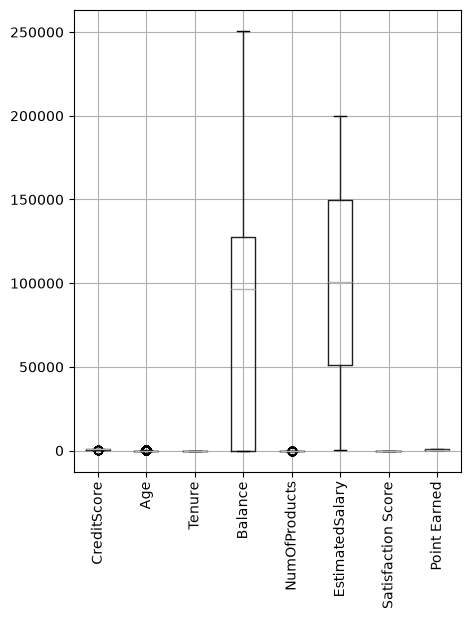

In [29]:
train[eda_num_cols].boxplot(figsize=(5,6))
plt.xticks(rotation=90)
plt.show()

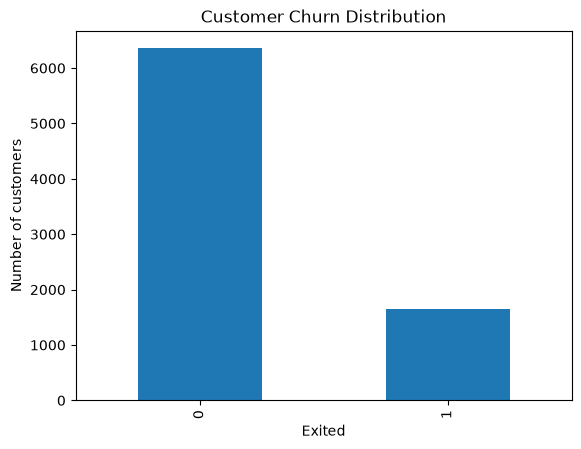

In [30]:
train["Exited"].value_counts().plot(kind="bar")

plt.xlabel("Exited")
plt.ylabel("Number of customers")
plt.title("Customer Churn Distribution")
plt.show()

In [31]:
drop_cols=["RowNumber", "CustomerId", "Surname"]

In [32]:
train=train.drop(columns=drop_cols)


In [33]:
test=test.drop(columns=drop_cols)

In [34]:
train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,686,France,Male,32,6,0.00,2,1,1,179093.26,0,0,2,DIAMOND,510
1,632,Germany,Male,42,4,119624.60,2,1,1,195978.86,0,0,4,PLATINUM,959
2,559,Spain,Male,24,3,114739.92,1,1,0,85891.02,1,1,4,SILVER,327
3,561,France,Female,27,9,135637.00,1,1,0,153080.40,1,1,2,SILVER,567
4,517,France,Male,56,9,142147.32,1,0,0,39488.04,1,1,3,PLATINUM,727


In [35]:
test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0,1,GOLD,709
1,623,France,Male,43,1,0.00,2,1,1,146379.30,0,2,SILVER,508
2,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0,1,GOLD,281
3,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0,2,SILVER,979
4,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0,5,SILVER,457


In [36]:
x=train.drop("Exited",axis=1)
y=train["Exited"]

In [37]:
x.shape

(8000, 14)

In [38]:
y.shape

(8000,)

In [39]:
x.dtypes

CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [42]:
x_train.shape

(6400, 14)

In [43]:
x_test.shape

(1600, 14)

In [44]:
y_train.shape

(6400,)

In [45]:
y_test.shape

(1600,)

In [46]:
cat_cols=x.select_dtypes(include="object").columns
cat_cols

C:\Users\jaswa\AppData\Local\Temp\ipykernel_4596\2663316364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=x.select_dtypes(include="object").columns


Index(['Geography', 'Gender', 'Card Type'], dtype='str')

In [47]:
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [48]:
x_train_cat=encoder.fit_transform(x_train[cat_cols])
x_val_cat = encoder.transform(x_test[cat_cols])

In [49]:
print(x_train_cat.shape)
print(x_val_cat.shape)

(6400, 9)
(1600, 9)


In [50]:
print(encoder.get_feature_names_out())

['Geography_France' 'Geography_Germany' 'Geography_Spain' 'Gender_Female'
 'Gender_Male' 'Card Type_DIAMOND' 'Card Type_GOLD' 'Card Type_PLATINUM'
 'Card Type_SILVER']


In [51]:
nums_cols=x.select_dtypes(include="number").columns
nums_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score',
       'Point Earned'],
      dtype='str')

In [52]:
x_train_num=x_train[nums_cols]
x_val_num=x_test[nums_cols]

In [53]:
print(x_train_num.shape)
print(x_val_num.shape)


(6400, 11)
(1600, 11)


In [54]:
import numpy as np

X_train_processed = np.hstack([x_train_num, x_train_cat])
X_val_processed = np.hstack([x_val_num, x_val_cat])

In [55]:
print(X_train_processed.shape)
print(X_val_processed.shape)

(6400, 20)
(1600, 20)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

In [57]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)

(6400, 20)
(1600, 20)


In [58]:
print(X_train_scaled[0])

[-0.3609952   0.86632153  0.68084637 -1.22098572 -0.91325136  0.64881365
 -1.01988517 -1.50556286  1.96362985 -0.01245045  0.75070374  0.99843872
 -0.57422293 -0.57927478 -0.91687908  0.91687908 -0.57927478 -0.57807196
  1.7071535  -0.56628336]


In [59]:
import sys
sys.path.append("..")

In [60]:
from knn import KNN

In [61]:
model = KNN(k=5)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

print(type(y_pred))
print(y_pred.shape)
print(y_pred[:10])

<class 'numpy.ndarray'>
(1600,)
[0 0 1 0 0 1 0 0 0 0]
